  0%|          | 0/9121 [00:00<?, ?it/s]

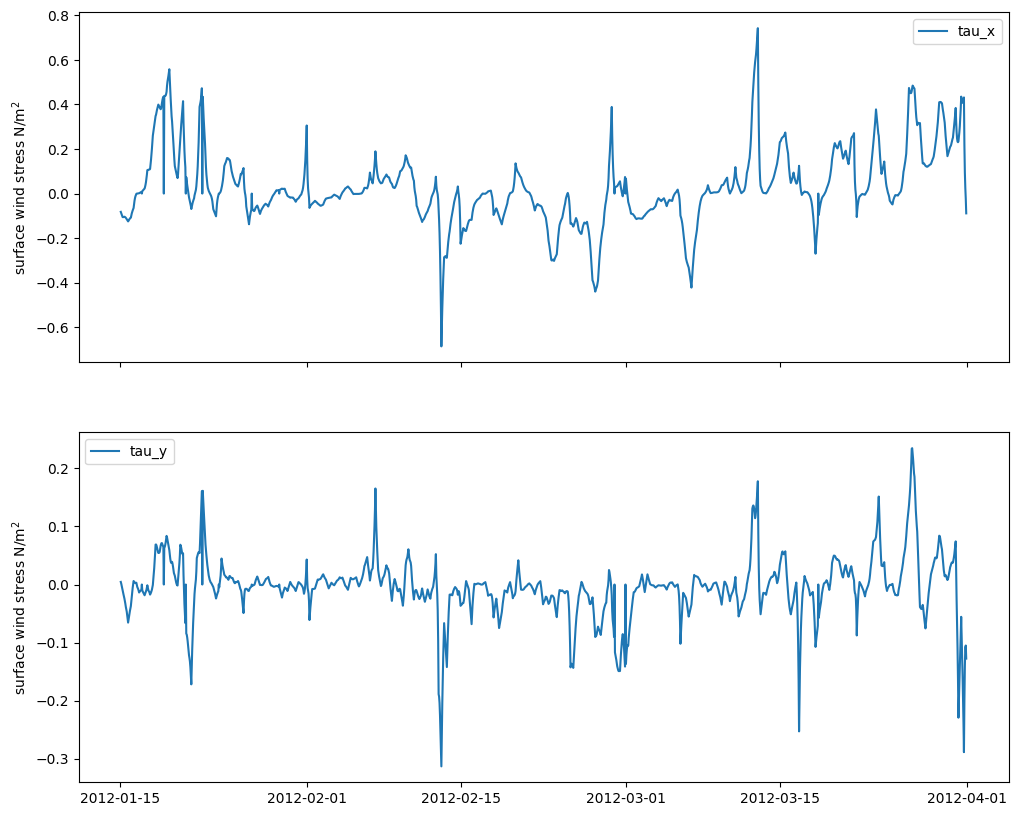

In [1]:
import numpy as np
from datetime import datetime
from datetime import timedelta
import os
import sys
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

def get_data_paths_from_binary(path_to_data,variable,delim='.',file_end='1'):
    '''This function returns a list of file names and paths with filenames to the files that you want given the path to the data and the varible directory. Returns sorted
        e.g.
        path_to_data = ./home/user/data/ 
        varible = var1
        get_data_path_from_binary(path_to_data,variable,delim='.',file_end='1')
        where delim,file_end selects for what file ending will be chosen
        returns
        ['d.a.t.a1.1','d.a.t.a2.1','d.a.t.a3.1'],['./home/user/data/var1/d.a.t.a1.1',''./home/user/data/var1/d.a.t.a2.1'',''./home/user/data/var1/d.a.t.a3.1'']
        '''
    all_paths = []
    filename_ = []
    for filename in os.listdir(path_to_data + variable):
        f = os.path.join(path_to_data,variable, filename)
    # checking if it is a file
        if filename.split(delim)[-1]==file_end:
            all_paths.append(filename)
            filename_.append(f)
    return sorted(all_paths), sorted(filename_)


def convert_itter_to_datetime(number,datetime_start,timestep,shift_itter=0):
    '''converts an itteration number to a datetime'''
    itter_dt = datetime.fromtimestamp(datetime_start.timestamp()+(int(number)+int(shift_itter))*timestep)
    return itter_dt
location = (0,10)

bin_path = '/mnt/thesis_model_data/Data/LLC4320/norcal_surf/'
variables = ['Eta','Theta','Salt','U','V','W','oceTAUX','oceTAUY']

y_stress_bin_files, y_stress_bin_filepath = get_data_paths_from_binary(bin_path,variables[-1])
x_stress_bin_files, x_stress_bin_filepath = get_data_paths_from_binary(bin_path,variables[-2],file_end='1_Neg')

i_ind_buoy = 804
j_ind_buoy = 358
j0 = np.arange(672)
i0 = np.arange(1486)
x_stress_values = []
y_stress_values = []
time_span = []'
date_range = [datetime(2012, 1, 15, 0),datetime(2012, 4, 1, 0)]
for i in tqdm(range(0,len(x_stress_bin_files))):
    time_itter=x_stress_bin_files[i][location[0]:location[1]]
    time = [convert_itter_to_datetime(time_itter,datetime(2011,9,10),25)]
    shape = (len(i0),len(j0))
    if (time[0]>date_range[0])and(time[0]<date_range[1]):
        file_x = np.fromfile(x_stress_bin_filepath[i],'>f4')
        file_x = np.reshape(file_x, shape)
        file_y = np.fromfile(y_stress_bin_filepath[i],'>f4')
        file_y = np.reshape(file_y, shape)
        x_stress_values.append(file_x[i_ind_buoy,j_ind_buoy])
        y_stress_values.append(file_y[i_ind_buoy,j_ind_buoy])
        time_span.append(time[0])

fig,ax = plt.subplots(ncols=1, nrows=2,figsize=(12,10),sharex=True)
ax[0].plot(time_span,x_stress_values,label='tau_x')
ax[1].plot(time_span,y_stress_values,label='tau_y')
ax[0].set_ylabel('surface wind stress N/m$^2$')
ax[1].set_ylabel('surface wind stress N/m$^2$')

ax[0].legend()
ax[1].legend()